# Week 2 — Pretrained Water Segmentation Using Multispectral and Optical Data

**Goal:** fine-tune an ImageNet-pretrained segmentation model (ResNet34 encoder + U-Net decoder, via
`segmentation-models-pytorch`) on the 12-channel water dataset and compare it with the Week 1 U-Net trained from scratch.

All reusable code lives in `src/` (preprocessing, data, model, losses, metrics, training engine, analysis, reporting);
this notebook only **explains, runs and displays**. The same pipeline can be run from the terminal with
`python scripts/run_week2.py`.

Fairness of the comparison: same Week 1 split (`config/split_v2.csv`), same train-derived normalisation
(`config/stats.json`), same metrics/threshold and the same seeds (42, 123, 2026).
A **random-init control** (identical architecture, no ImageNet weights) is trained as well, so the effect of
*pretraining* can be separated from the effect of the *larger architecture*.

## 1. Setup

In [53]:
%pip install -q "segmentation-models-pytorch==0.5.0" tifffile

import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/just0neball/Water-Segmentation-using-Multispectral-and-Optical.git"

here = Path.cwd()
ROOT = next((p for p in (here, here.parent, here / "week2", here.parent / "week2")
             if (p / "src" / "pipeline.py").exists()), None)
if ROOT is None:                                   # e.g. a fresh Kaggle session
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "/kaggle/working/repo"], check=True)
    ROOT = Path("/kaggle/working/repo/week2")
sys.path.insert(0, str(ROOT))
print("Repository root:", ROOT)

Note: you may need to restart the kernel to use updated packages.
Repository root: /kaggle/working/week2


In [54]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display
from torch.utils.data import DataLoader

import segmentation_models_pytorch as smp

from src import analysis as an
from src import reporting as rp
from src.config import PipelineConfig
from src.data import build_datasets, build_file_maps, load_split, load_stats
from src.model import INIT_MEAN, INIT_RGB_ZERO, build_model
from src.pipeline import run_pipeline
from src.preprocessing import CHANNEL_NAMES

print(
    "torch", torch.__version__,
    "| smp", smp.__version__,
    "| CUDA:", torch.cuda.is_available()
)

# Dataset
KAGGLE_DATA = Path(
    "/kaggle/input/datasets/nebalelshobary/"
    "satellite-multispectral-water-segmentation"
)

DATA_ROOT = KAGGLE_DATA if KAGGLE_DATA.exists() else Path("data")
OUT_DIR = Path("/kaggle/working/week2_outputs")

# ============================================================
# Week 1 held-out test results
# ============================================================

week1_raw = pd.read_csv(
    "/kaggle/working/repo/results/"
    "final_vs_benchmark_test_results.csv"
)

week1_benchmark = week1_raw[
    (week1_raw["Architecture"] == "UNetBN") &
    (week1_raw["Experiment"] == "benchmark12")
].copy()

WEEK1_TEST_CSV = ROOT / "config" / "week1_test_metrics.csv"

pd.DataFrame({
    "Seed": week1_benchmark["Seed"].astype(int),
    "IoU": week1_benchmark["Test_Base_IoU"].astype(float),
    "F1": week1_benchmark["Test_Base_F1"].astype(float),
    "Precision": np.nan,
    "Recall": np.nan,
}).to_csv(
    WEEK1_TEST_CSV,
    index=False
)

WEEK1_PARAMS_M = 7.765633

print("Week 1 comparison file ready:", WEEK1_TEST_CSV)

# ============================================================
# Pipeline configuration
# ============================================================

cfg = PipelineConfig(
    data_root=DATA_ROOT,
    config_dir=ROOT / "config",
    out_dir=OUT_DIR,
    readme_path=ROOT / "README.md",
    week1_test_csv=WEEK1_TEST_CSV,
    week1_params_m=WEEK1_PARAMS_M,

    # Exact Week 1 loss
    bce_weight=1.0,
    dice_weight=1.0,
    dice_mode="per_image",
)

print(cfg.to_dict())

torch 2.11.0+cu128 | smp 0.5.0 | CUDA: True
Week 1 comparison file ready: /kaggle/working/week2/config/week1_test_metrics.csv
{'data_root': '/kaggle/input/datasets/nebalelshobary/satellite-multispectral-water-segmentation', 'config_dir': '/kaggle/working/week2/config', 'out_dir': '/kaggle/working/week2_outputs', 'readme_path': '/kaggle/working/week2/README.md', 'seeds': (42, 123, 2026), 'strategies': ('mean', 'rgb_zero_extra'), 'ablation_random_init': True, 'encoder': 'resnet34', 'decoder': 'unet', 'in_channels': 12, 'batch_size': 16, 'max_epochs': 100, 'patience': 15, 'encoder_lr': 0.0001, 'decoder_lr': 0.001, 'weight_decay': 0.0001, 'threshold': 0.5, 'num_workers': 0, 'bce_weight': 1.0, 'dice_weight': 1.0, 'dice_mode': 'per_image', 'log_every': 5, 'resume': True, 'week1_results': None, 'week1_test_csv': '/kaggle/working/week2/config/week1_test_metrics.csv', 'week1_params_m': 7.765633}


## 2. Dataset and 12-channel preprocessing

Each sample is a 12-band `128×128` GeoTIFF with a binary water mask. Only bands 0–6 are true spectral bands;
the remaining ones are QA, two DEMs, ESA WorldCover and Water Occurrence (see the Week 1 notebook for the audit of
possible shortcut features). Every band is normalised with statistics computed on the **training split only**.

In [55]:
image_map, mask_map = build_file_maps(cfg.images_dir, cfg.masks_dir)
split_df, train_df, val_df, test_df = load_split(cfg.split_path)
stats = load_stats(cfg.stats_path)
datasets = build_datasets(train_df, val_df, test_df, image_map, mask_map, stats)

print(f"image/mask pairs: {len(image_map)} | train/val/test: {len(train_df)}/{len(val_df)}/{len(test_df)}")
display(split_df.groupby(["Coverage_Group", "Split"]).size().unstack(fill_value=0))

x, y, sample_id = datasets["train"][0]
print("sample", sample_id, "| image", tuple(x.shape), "| mask", tuple(y.shape), "| finite:", bool(torch.isfinite(x).all()))
assert tuple(x.shape) == (12, 128, 128)          # required output shape of the preprocessing pipeline
print("Channels:", ", ".join(f"{i}:{n}" for i, n in enumerate(CHANNEL_NAMES)))

image/mask pairs: 306 | train/val/test: 214/46/46


Split,Test,Train,Validation
Coverage_Group,,,
High (50-80%),7,34,7
Low (5-20%),7,32,7
Medium (20-50%),12,54,11
No Water,7,31,7
Very High (80-100%),2,13,3
Very Low (0-5%),11,50,11


sample 153 | image (12, 128, 128) | mask (1, 128, 128) | finite: True
Channels: 0:Coastal, 1:Blue, 2:Green, 3:Red, 4:NIR, 5:SWIR1, 6:SWIR2, 7:QA, 8:MERIT DEM, 9:Copernicus DEM, 10:ESA WorldCover, 11:Water Occurrence


## 3. Pretrained backbone research

Candidate ImageNet encoders available in `segmentation-models-pytorch`:

| Backbone | Idea | Trade-off |
|---|---|---|
| ResNet18 / 34 / 50 | residual blocks, skip connections ease optimisation | deeper = more capacity, more memory |
| EfficientNet-B0 / B3 | compound scaling of depth/width/resolution, few parameters | depth-wise convs; more sensitive to small data and BatchNorm statistics |

**Choice: ResNet34** — a good capacity/stability trade-off for only 306 patches of 128×128, and its stride-2 stem plus
four residual stages give the multi-scale features a U-Net decoder needs.

**Decoder: U-Net** (matches the Week 1 baseline, skip connections preserve fine water boundaries).
**DeepLabV3+** (Chen et al., arXiv:1606.00915 — atrous/dilated convolutions and Atrous Spatial Pyramid Pooling
enlarge the receptive field without losing resolution) is a valid alternative and can be tried with
`--decoder deeplabv3plus`; it is not part of the main comparison so that only *one* factor changes versus Week 1.

In [57]:
rows = []
for name, strength, limit in [
    ("resnet18", "light, fast, stable", "lowest capacity"),
    ("resnet34", "capacity / cost balance (selected)", "heavier than ResNet18"),
    ("resnet50", "bottleneck blocks, high capacity", "more compute and memory"),
    ("efficientnet-b0", "very parameter-efficient", "can be fragile on tiny datasets"),
    ("efficientnet-b3", "stronger EfficientNet variant", "higher compute cost"),
]:
    encoder = smp.encoders.get_encoder(name, in_channels=3, depth=5, weights=None)
    rows.append({"Backbone": name, "Encoder params (M)": sum(p.numel() for p in encoder.parameters()) / 1e6,
                 "Strength": strength, "Limitation": limit})
backbone_df = pd.DataFrame(rows)
display(backbone_df.style.format({"Encoder params (M)": "{:.2f}"}))

,Backbone,Encoder params (M),Strength,Limitation
0,resnet18,11.18,"light, fast, stable",lowest capacity
1,resnet34,21.28,capacity / cost balance (selected),heavier than ResNet18
2,resnet50,23.51,"bottleneck blocks, high capacity",more compute and memory
3,efficientnet-b0,4.01,very parameter-efficient,can be fragile on tiny datasets
4,efficientnet-b3,10.70,stronger EfficientNet variant,higher compute cost


## 4. Adapting the first convolution from 3 to 12 channels

ImageNet weights exist only for RGB. The stem conv is replaced by a 12-channel conv in two ways:

* **`mean`** — average the R/G/B filters, repeat over 12 channels, scale by 3/12 (keeps the activation scale).
* **`rgb_zero_extra`** — put the R/G/B filters on the dataset's Red/Green/Blue bands (channels 3/2/1 — the dataset
  order is Coastal, Blue, Green, Red, …, *not* R, G, B) and zero-initialise the other nine channels.

Both are trained under identical conditions and the winner is chosen on **mean validation IoU over all seeds**.

In [58]:
model_mean = build_model("resnet34", "unet", INIT_MEAN)
model_rgb = build_model("resnet34", "unet", INIT_RGB_ZERO)

print("first conv (mean):", model_mean.encoder.conv1)
w = model_rgb.encoder.conv1.weight
print("rgb_zero_extra non-zero input channels:", (w.abs().sum(dim=(0, 2, 3)) > 0).nonzero().flatten().tolist(), "(expected [1, 2, 3])")
assert model_mean.encoder.conv1.in_channels == 12 and model_rgb.encoder.conv1.in_channels == 12

# forward-pass sanity check on one real validation batch
images, masks, _ = next(iter(DataLoader(datasets["val"], batch_size=8)))
with torch.no_grad():
    logits = model_mean.eval()(images)
print("input", tuple(images.shape), "-> logits", tuple(logits.shape))
assert logits.shape == masks.shape and torch.isfinite(logits).all()
del model_mean, model_rgb, logits

first conv (mean): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
rgb_zero_extra non-zero input channels: [1, 2, 3] (expected [1, 2, 3])
input (8, 12, 128, 128) -> logits (8, 1, 128, 128)


## 5. Fine-tuning and evaluation

`run_pipeline` trains every (init strategy × seed) combination plus the random-init control with:
BCE + Dice loss, AdamW (encoder LR 1e-4, decoder LR 1e-3, weight decay 1e-4), `ReduceLROnPlateau`,
mixed precision, early stopping on validation IoU (patience 15, max 100 epochs) and best-checkpoint restoration.
Finished runs are reused automatically if the session restarts (`resume=True`).
The held-out **test set is evaluated only after** the initialisation strategy has been selected on validation data.

Device: cuda | pairs: 306 | train/val/test: 214/46/46

=== resnet34_unet_mean_seed42 ===
  epoch 001 | train loss 1.2316 | val loss 2.2978 | IoU 0.4301 | F1 0.6015 | P 0.4395 | R 0.9523  *
  epoch 002 | train loss 0.9654 | val loss 0.9054 | IoU 0.6413 | F1 0.7814 | P 0.7713 | R 0.7918  *
  epoch 003 | train loss 0.8958 | val loss 0.8230 | IoU 0.6810 | F1 0.8103 | P 0.9127 | R 0.7285  *
  epoch 004 | train loss 0.8741 | val loss 0.7747 | IoU 0.6953 | F1 0.8203 | P 0.8990 | R 0.7542  *
  epoch 005 | train loss 0.8138 | val loss 0.7666 | IoU 0.7007 | F1 0.8240 | P 0.8620 | R 0.7892  *
  epoch 006 | train loss 0.7873 | val loss 0.7468 | IoU 0.7116 | F1 0.8315 | P 0.8817 | R 0.7867  *
  epoch 007 | train loss 0.7758 | val loss 0.7268 | IoU 0.7230 | F1 0.8392 | P 0.8592 | R 0.8202  *
  epoch 008 | train loss 0.7577 | val loss 0.7386 | IoU 0.7245 | F1 0.8402 | P 0.9266 | R 0.7686  *
  epoch 010 | train loss 0.7349 | val loss 0.7244 | IoU 0.7293 | F1 0.8435 | P 0.9231 | R 0.7765  *
  epoch 015

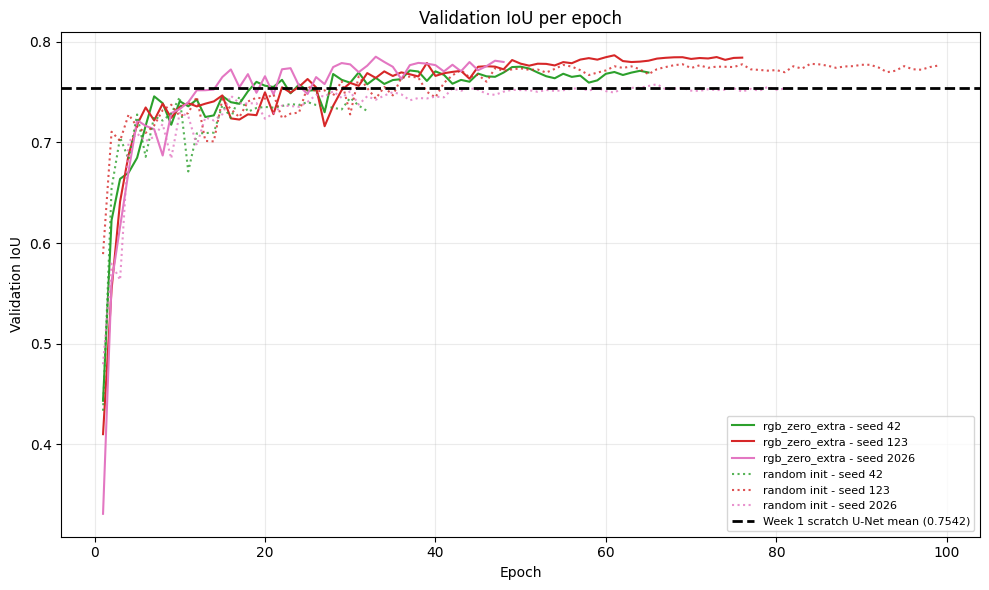

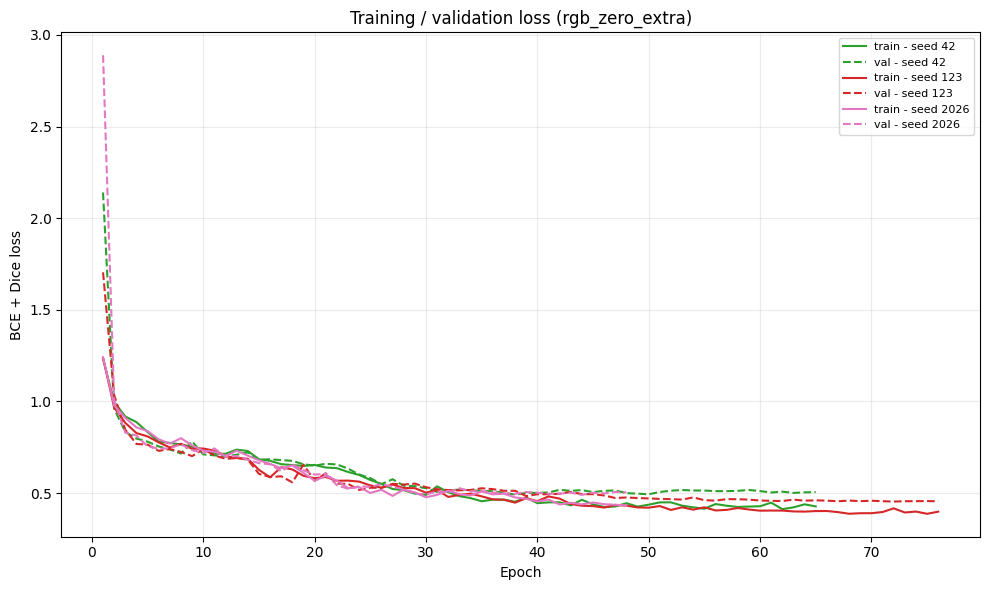

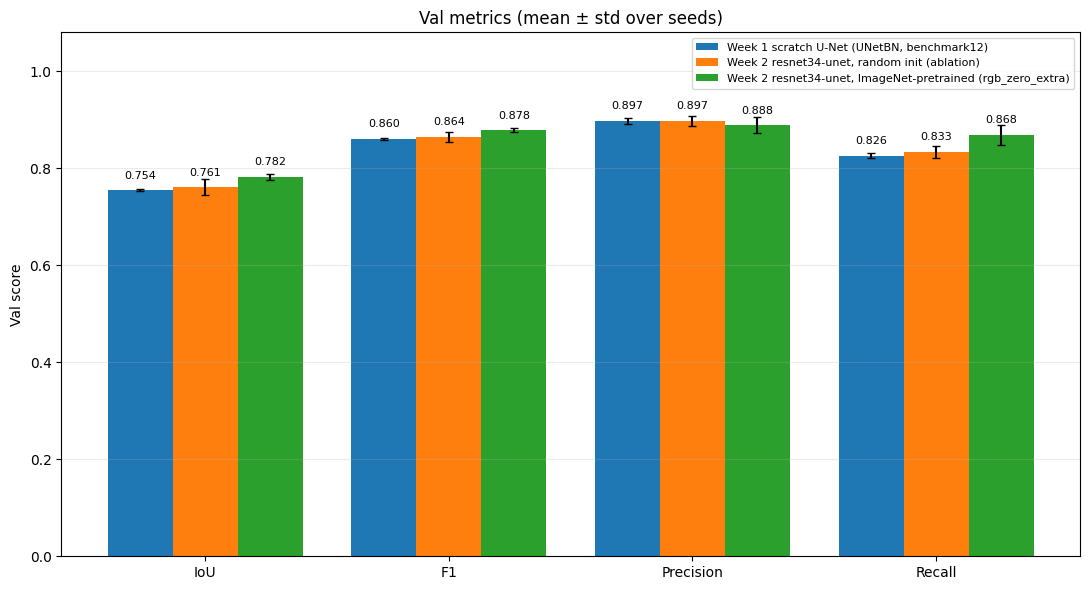

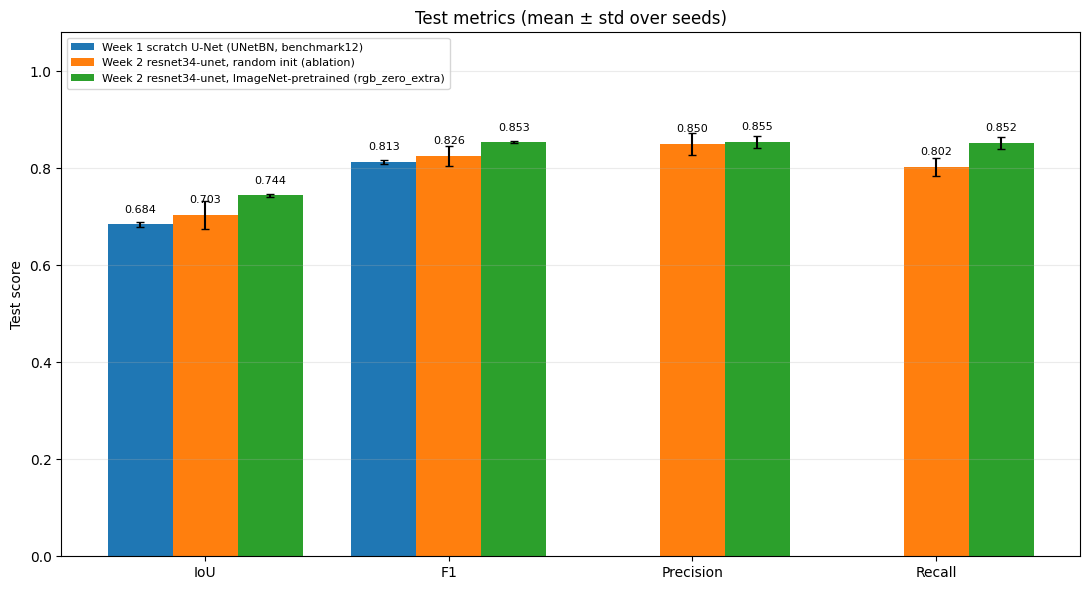

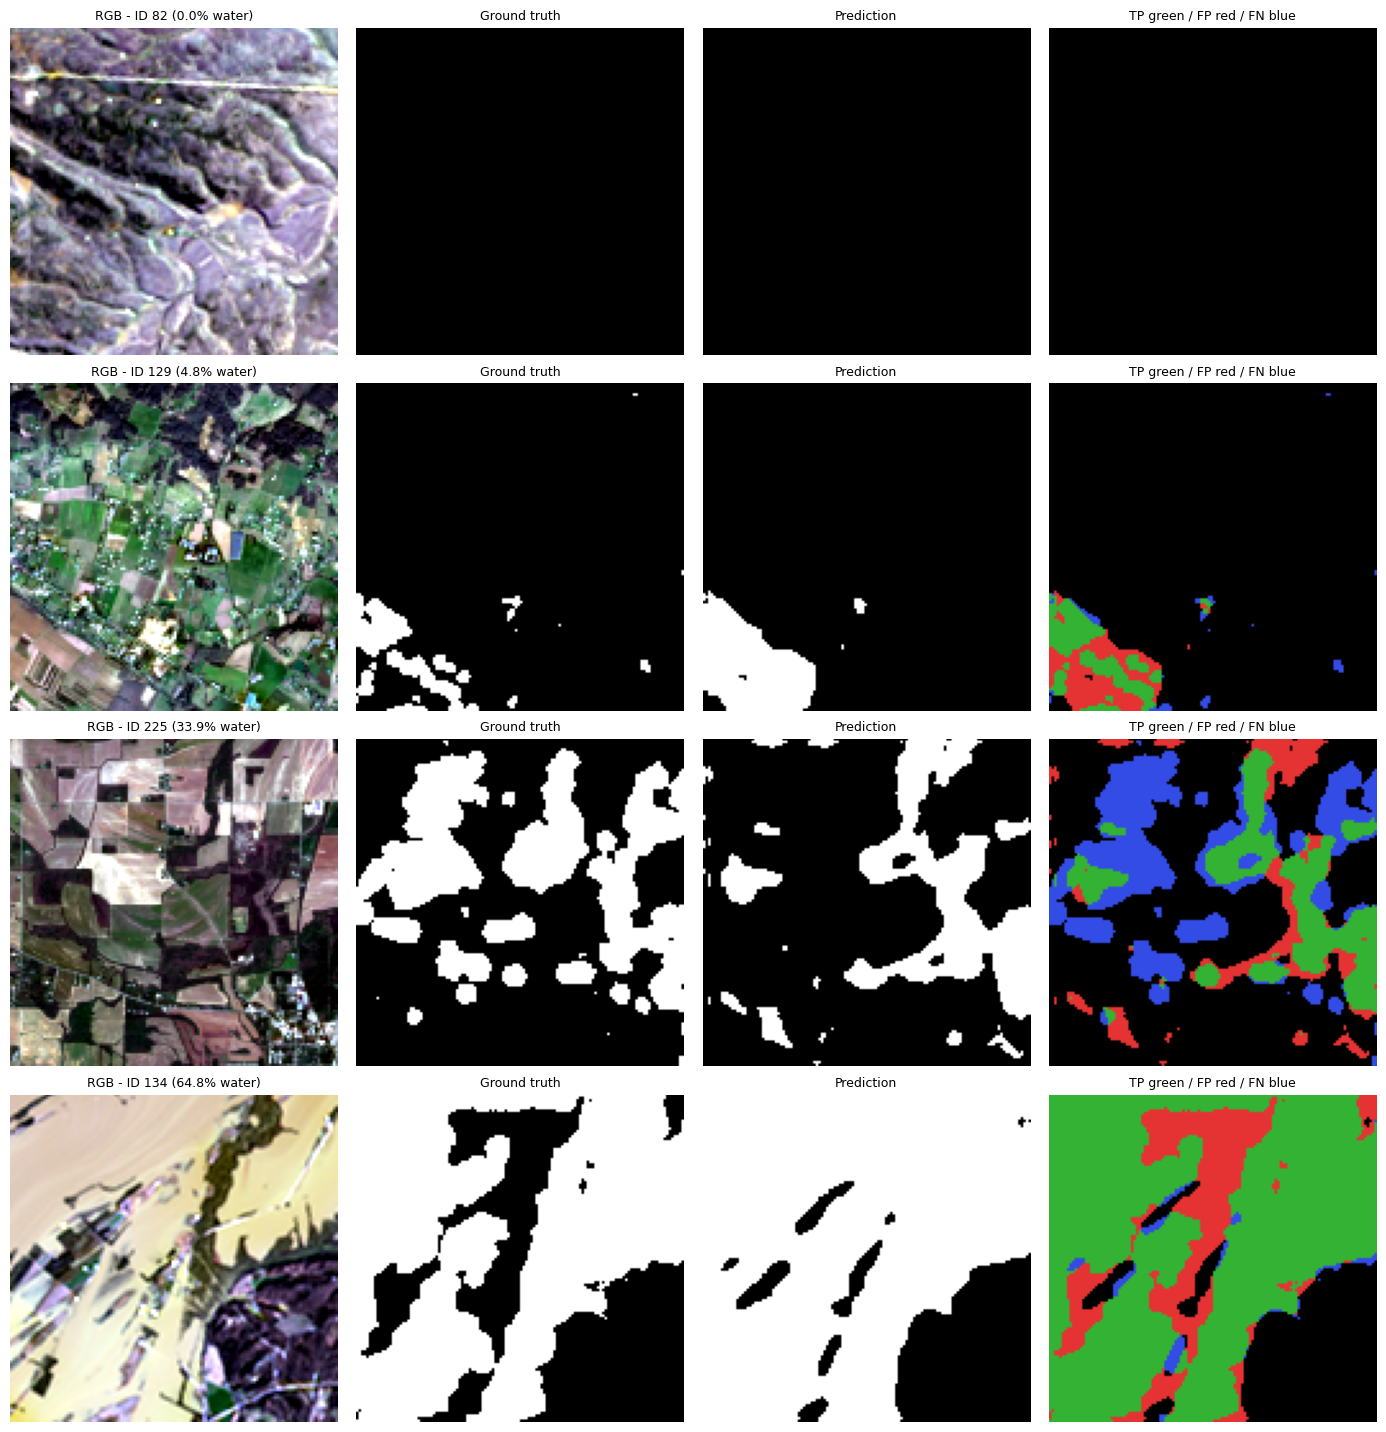


Done. Results written to /kaggle/working/week2_outputs

Selected first-conv initialisation: rgb_zero_extra


In [59]:
res = run_pipeline(cfg, show_figures=True)
print("\nSelected first-conv initialisation:", res["selected"])

## 6. Results

In [60]:
display(Markdown("### Model comparison (mean ± std over seeds)"))
display(res["model_comparison"])
display(Markdown("### Per-seed validation IoU"))
display(res["paired_val_iou"])
if res["paired_test_iou"] is not None:
    display(Markdown("### Per-seed test IoU"))
    display(res["paired_test_iou"])
display(Markdown("### First-layer initialisation strategies"))
display(res["strategy_table"])

### Model comparison (mean ± std over seeds)

,Model,Params (M),Val IoU,Val F1,Val Precision,Val Recall,Test IoU,Test F1,Test Precision,Test Recall
0,"Week 1 scratch U-Net (UNetBN, benchmark12)",7.77,0.7542 ± 0.0021,0.8599 ± 0.0013,0.8972 ± 0.0058,0.8257 ± 0.0056,0.6845 ± 0.0055,0.8127 ± 0.0039,nan,nan
1,"Week 2 resnet34-unet, random init (ablation)",24.46,0.7606 ± 0.0165,0.8639 ± 0.0106,0.8972 ± 0.0107,0.8331 ± 0.0130,0.7032 ± 0.0289,0.8255 ± 0.0200,0.8501 ± 0.0221,0.8024 ± 0.0183
2,"Week 2 resnet34-unet, ImageNet-pretrained (rgb...",24.46,0.7825 ± 0.0062,0.8779 ± 0.0039,0.8884 ± 0.0164,0.8683 ± 0.0213,0.7440 ± 0.0031,0.8532 ± 0.0021,0.8545 ± 0.0126,0.8521 ± 0.0122


### Per-seed validation IoU

,Seed,Week 1 scratch,Pretrained,Random init,Δ Pretrained − Week 1 scratch,Δ Random init − Week 1 scratch
0,42,0.756320,0.775360,0.745600,0.019040,-0.010720
1,123,0.752195,0.786736,0.778206,0.034541,0.026011
2,2026,0.754214,0.785294,0.757944,0.031079,0.003729


### Per-seed test IoU

,Seed,Week 1 scratch,Pretrained,Random init,Δ Pretrained − Week 1 scratch,Δ Random init − Week 1 scratch
0,42,0.679199,0.741037,0.671324,0.061838,-0.007875
1,123,0.684003,0.747275,0.727602,0.063272,0.043599
2,2026,0.690267,0.743674,0.710823,0.053407,0.020556


### First-layer initialisation strategies

,Strategy,Seed 42,Seed 123,Seed 2026,Mean ± Std
0,rgb_zero_extra,0.775360,0.786736,0.785294,0.7825 ± 0.0062
1,mean,0.766482,0.767355,0.785573,0.7731 ± 0.0108


In [61]:
display(Markdown("### Held-out test results, every run"))
display(res["runs_test"])
display(Markdown("### Error analysis by water coverage (selected model, test)"))
display(res["coverage_test"])

### Held-out test results, every run

,Run,Strategy,Seed,Test_IoU,Test_F1,Test_Precision,Test_Recall,Test_Loss,Test_MeanImageIoU_waterOnly,Val_MeanImageIoU_waterOnly
0,resnet34_unet_mean_seed42,mean,42,0.719101,0.836601,0.828387,0.844980,0.516173,0.571618,0.558144
1,resnet34_unet_mean_seed123,mean,123,0.736181,0.848047,0.850728,0.845382,0.450327,0.599866,0.562171
2,resnet34_unet_mean_seed2026,mean,2026,0.753315,0.859304,0.865789,0.852915,0.431451,0.606854,0.576423
3,resnet34_unet_rgb_zero_extra_seed42,rgb_zero_extra,42,0.741037,0.851259,0.859088,0.843572,0.481792,0.589905,0.555153
4,resnet34_unet_rgb_zero_extra_seed123,rgb_zero_extra,123,0.747275,0.855360,0.864244,0.846658,0.452760,0.615656,0.584156
5,resnet34_unet_rgb_zero_extra_seed2026,rgb_zero_extra,2026,0.743674,0.852997,0.840318,0.866064,0.517331,0.569550,0.550495
6,resnet34_unet_random_init_seed42,random_init,42,0.671324,0.803344,0.825210,0.782607,0.724421,0.539561,0.537218
7,resnet34_unet_random_init_seed123,random_init,123,0.727602,0.842326,0.867227,0.818814,0.532788,0.559206,0.572124
8,resnet34_unet_random_init_seed2026,random_init,2026,0.710823,0.830972,0.857914,0.805670,0.522625,0.550252,0.548653


### Error analysis by water coverage (selected model, test)

,Coverage_Group,N_images,FP_Pixel_Rate,IoU,F1,Precision,Recall
0,No Water,21,0.005342,NaN,NaN,NaN,NaN
1,Very Low (0-5%),33,0.011321,0.442741,0.613750,0.561093,0.677313
2,Low (5-20%),21,0.019139,0.545586,0.705992,0.807366,0.627236
3,Medium (20-50%),36,0.044686,0.699958,0.823500,0.867053,0.784114
4,High (50-80%),21,0.113389,0.770802,0.870568,0.824965,0.921508
5,Very High (80-100%),6,0.024811,0.966888,0.983165,0.974097,0.992404


## 7. Findings (generated from the numbers)

In [62]:
display(Markdown(rp.make_findings(res)))
display(Markdown("**Limitations**\n\n" + rp.LIMITATIONS))

- **Pretrained vs Week 1 scratch (validation):** mean IoU 0.7825 ± 0.0062 vs 0.7542 ± 0.0021 (Δ = +0.0282); higher in 3/3 seeds.
  - Precision: -0.0088
  - Recall: +0.0426
  - F1: +0.0180
- **Held-out test:** mean IoU 0.7440 (pretrained) vs 0.6845 (Week 1 scratch), Δ = +0.0595. The test set was not used for any selection, so this is the less optimistic comparison (validation IoU was used for early stopping in both weeks).
- **Ablation (same ResNet34 architecture, random init):** val IoU 0.7606 ± 0.0165 vs 0.7825 ± 0.0062 pretrained (Δ = +0.0219); the gap exceeds the seed-to-seed spread, which suggests the ImageNet weights contribute beyond architecture and capacity (still only 3 seeds).
  - The random-init ResNet34-U-Net already beats the Week 1 model by +0.0063 IoU, so part of the improvement is architectural.
- **First-conv initialisation:** `rgb_zero_extra` (0.7825) vs `mean` (0.7731) - gap +0.0093, within seed variability, so the choice is not statistically meaningful.
- **Capacity:** Week 2 model 24.46 M parameters vs Week 1 7.77 M.

**Limitations**

- Only 3 seeds and a single 214/46/46 split; validation has just 46 patches, so small differences are noisy.
- Validation IoU drives early stopping (and the init-strategy choice), so validation numbers are optimistic for
  every model; the held-out test numbers are the unbiased estimate.
- Hyper-parameters were reused from Week 1 and not tuned for the pretrained model.
- The 12 channels include QA, ESA WorldCover and Water Occurrence, which can act as shortcut features
  (see the Week 1 shortcut audit). Results therefore describe this 12-channel setting, not pure spectral learning.
- ImageNet RGB statistics differ strongly from NIR/SWIR/DEM/categorical channels; the benefit of the pretrained
  *first* layer is limited, most transferable value is expected in deeper layers (a hypothesis, not tested here).

## 8. Task checklist

| Week 2 requirement | Where |
|---|---|
| Research pretrained backbones | Section 3 |
| Adapt first conv to 12 channels (averaging / zero-init) | Section 4, `src/model.py` |
| `segmentation-models-pytorch` encoder + U-Net (DeepLabV3+ optional) | `src/model.py` |
| Fine-tune on the water dataset | Section 5, `src/engine.py` |
| Compare with the Week 1 scratch U-Net (IoU, F1, Precision, Recall) | Section 6 |
| Document which model is better and why | Section 7 (+ random-init ablation) |
| Clean, modular code in the repository | `src/`, `scripts/`, `tests/` |